In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report

# Tworzenie DataFrame z Twoich danych
df_csv = pd.read_csv('SalesDataset.csv')
df = df_csv.copy().drop(columns=['Unnamed: 0'])

# Konwersja daty - ważne dla hipotezy o miesiącach
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

df.head()

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,2023-11-24,Male,34,Beauty,3,50,150,11
1,2023-02-27,Female,26,Clothing,2,500,1000,2
2,2023-01-13,Male,50,Electronics,1,30,30,1
3,2023-05-21,Male,37,Clothing,1,500,500,5
4,2023-05-06,Male,30,Beauty,2,50,100,5


                                Date         Age     Quantity  Price per Unit  \
count                           1000  1000.00000  1000.000000     1000.000000   
mean   2023-07-03 00:25:55.200000256    41.39200     2.514000      179.890000   
min              2023-01-01 00:00:00    18.00000     1.000000       25.000000   
25%              2023-04-08 00:00:00    29.00000     1.000000       30.000000   
50%              2023-06-29 12:00:00    42.00000     3.000000       50.000000   
75%              2023-10-04 00:00:00    53.00000     4.000000      300.000000   
max              2024-01-01 00:00:00    64.00000     4.000000      500.000000   
std                              NaN    13.68143     1.132734      189.681356   

       Total Amount        Month  
count   1000.000000  1000.000000  
mean     456.000000     6.549000  
min       25.000000     1.000000  
25%       60.000000     4.000000  
50%      135.000000     6.000000  
75%      900.000000    10.000000  
max     2000.000000    12

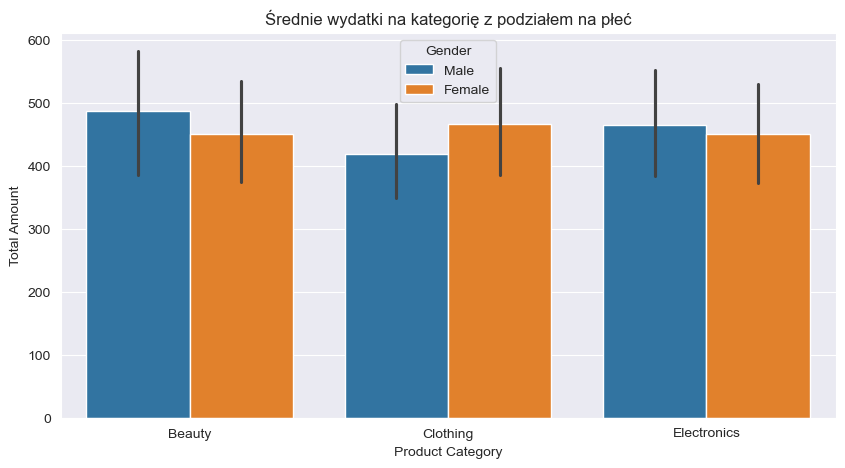

In [6]:
# Sprawdzenie podstawowych statystyk
print(df.describe())

# Wizualizacja: Średnie wydatki według płci i kategorii
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender')
plt.title("Średnie wydatki na kategorię z podziałem na płeć")
plt.show()

In [7]:
# 1. Kodowanie zmiennych kategorycznych (One-Hot Encoding)
# Zamieniamy tekst na kolumny 0 i 1
df_ml = pd.get_dummies(df, columns=['Gender', 'Product Category'], drop_first=True)

# 2. Wybór cech (X) i celu (y)
# Usuwamy datę (mamy już miesiąc) i Total Amount (to nasz cel)
X = df_ml.drop(['Total Amount', 'Date'], axis=1)
y = df_ml['Total Amount']

# 3. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Skalowanie danych (ważne dla modeli liniowych)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
~~~~reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

y_pred = reg_model.predict(X_test_scaled)

print(f"Błąd średniokwadratowy (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd bezwzględny (MAE): {mean_absolute_error(y_test, y_pred):.2f}")

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (55142641.py, line 1)

In [5]:
# Przygotowanie danych pod klasyfikację płci
y_class = df_ml['Gender_Male']
X_class = df_ml.drop(['Gender_Male', 'Date', 'Total Amount'], axis=1)

X_t, X_v, y_t, y_v = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

clf = LogisticRegression()
clf.fit(X_t, y_t)
y_pred_class = clf.predict(X_v)

print(f"Dokładność modelu: {accuracy_score(y_v, y_pred_class) * 100:.2f}%")

Dokładność modelu: 48.00%


D:\Programy\_Coding\Miniconda3\envs\Env1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
